# Hybrid 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random 
import tensorflow as tf
from math import sqrt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
# from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from keras.models import Sequential
from keras.layers import GRU, Dropout, SimpleRNN, Dense, LSTM
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau 

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Import Data

In [2]:
data = pd.read_csv("/Users/alexzheng/Developer/GitHub/EC331-project/data/Bitcoin_data.csv", 
                   index_col=0, 
                   parse_dates=True) # set index to datetime 

In [3]:
# Normalize the data 
scaler = MinMaxScaler()
data_normalized = scaler.fit_transform(data)

In [4]:
def create_sequences(data, window_size, target_col_idx):
    """
    data: NumPy array with all features (open, high, low, close)
    window_size: Number of past time steps to use
    target_col_idx: Index of the column to predict (close price = -1)
    """
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), :])  # Take all columns as input
        y.append(data[i + window_size, target_col_idx])  # Only the close price as output
    return np.array(X), np.array(y)

window_size = 15

target_col_idx = data.columns.get_loc("close")
X, y = create_sequences(data_normalized, window_size, target_col_idx=target_col_idx)

### Split

In [5]:
split = int(len(X) * 0.8)  # 80% training, 20% testing
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (47062, 15, 4)
y_train shape: (47062,)
X_test shape: (11766, 15, 4)
y_test shape: (11766,)


## Hybrid model

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 15, 30)         │         3,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30)             │         7,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,591 (41.37 KB)

 Trainable params: 10,591 (41.37 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.0120 - val_loss: 0.0023
Epoch 2/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 3/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0015 - val_loss: 0.0014
Epoch 4/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0012 - val_loss: 0.0021
Epoch 5/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011 - val_loss: 9.4445e-04
Epoch 6/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - val_loss: 5.7977e-04
Epoch 7/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - val_loss: 7.3243e-04
Epoch 8/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0010 - val_loss: 7.6549e-04
Epoch 9/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.8492e-04 - val_loss: 5.9002e-04
Epoch 10/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 9.7755e-04 - val_loss: 0.0013
Epoch 11/50
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 9.8364e-04 - val_loss: 7.8806e-04
Epoch

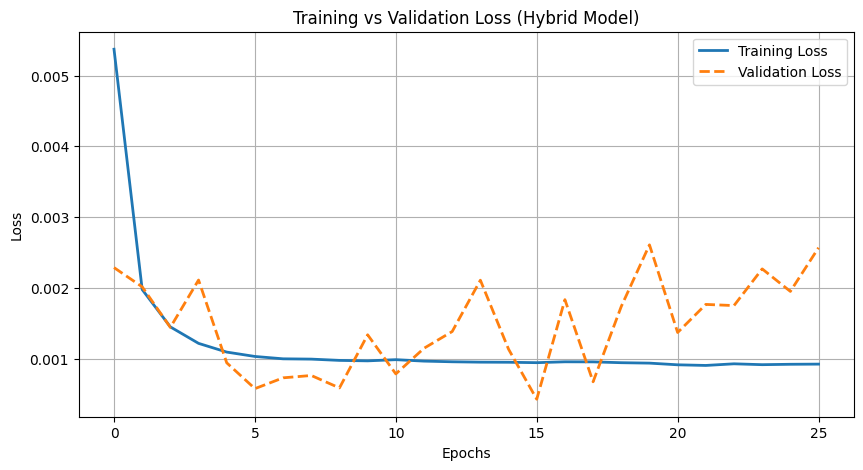

368/368 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step 
Hybrid Model Error Statistics:
Mean Absolute Error (MAE): 1242.7926
Root Mean Squared Error (RMSE): 2181.3492
Mean Absolute Percentage Error (MAPE): 1.65%


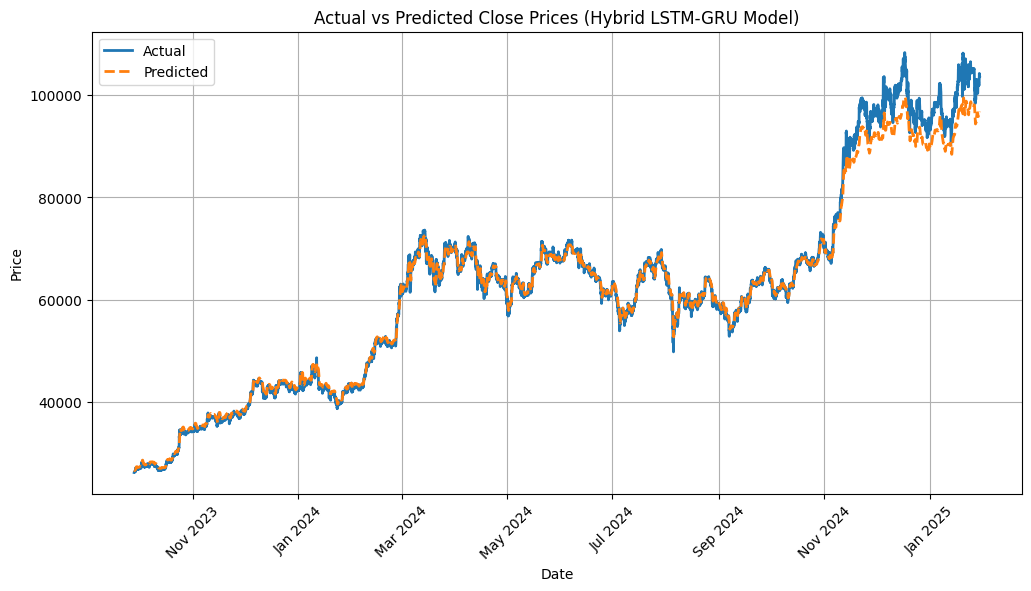

In [6]:
# Hybrid Model
hybrid_model = Sequential()

# One GRU layer
hybrid_model.add(GRU(30, return_sequences=True, recurrent_dropout=0.2, input_shape=(X_train.shape[1], X_train.shape[2])))
hybrid_model.add(Dropout(0.5))

# One LSTM layer 
hybrid_model.add(LSTM(30, return_sequences=False, recurrent_dropout=0.2))  
hybrid_model.add(Dropout(0.5))

# Output layer
hybrid_model.add(Dense(1))

# Compile the model
optimizer = tf.keras.optimizers.Adam()
hybrid_model.compile(optimizer=optimizer, loss='mean_squared_error')

# Model Summary
hybrid_model.summary()

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

# Train the Hybrid Model
history_hybrid = hybrid_model.fit(X_train, y_train, 
                                  epochs=50,  
                                  batch_size=256,  # Increased batch size for stability
                                  validation_data=(X_test, y_test), 
                                  callbacks=[early_stopping],  
                                  verbose=1)

# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history_hybrid.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history_hybrid.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss (Hybrid Model)')
plt.legend()
plt.grid(True)
plt.show()

# Make predictions
predicted_hybrid = hybrid_model.predict(X_test)

# Use a separate scaler for close prices
close_scaler = MinMaxScaler()
data['close'] = close_scaler.fit_transform(data[['close']])

# Inverse transform the predicted and actual values using the correct scaler
predicted_hybrid = close_scaler.inverse_transform(predicted_hybrid.reshape(-1, 1))  # Fixed reshaping issue
y_test_actual = close_scaler.inverse_transform(y_test.reshape(-1, 1))

# Evaluate model performance
mae = mean_absolute_error(y_test_actual, predicted_hybrid)
mse = mean_squared_error(y_test_actual, predicted_hybrid)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_test_actual - predicted_hybrid) / y_test_actual)) * 100  

# Print results
print(f"Hybrid Model Error Statistics:")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

# Plot Actual vs Predicted Prices
date_index = pd.to_datetime(data.index[-len(y_test_actual):])
plt.figure(figsize=(12, 6))
plt.plot(date_index, y_test_actual, label='Actual', linewidth=2)
plt.plot(date_index, predicted_hybrid, label='Predicted', linewidth=2, linestyle='dashed')

plt.title('Actual vs Predicted Close Prices (Hybrid LSTM-GRU Model)')
plt.xlabel('Date')
plt.ylabel('Price')

plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()